In [162]:
#### Statistical Tests and Analyses
import numpy as np
from scipy.stats import shapiro, ttest_rel, levene, wilcoxon, mannwhitneyu, ranksums
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import json
import sys

project_root = Path().resolve().parent.parent  # from inside src/analyze/

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

INSTA_FILE = project_root / "data/transformed/insta_final.csv"
POP_FILE = project_root / "data/transformed/pop_final.csv"
TT_FILE = project_root / "data/transformed/tt_final_country.csv"
FB_FILE = project_root / "data/transformed/fb_final.csv" 

FILE_NAMES = {INSTA_FILE: "Instagram", POP_FILE: "Population", TT_FILE: "TikTok", FB_FILE: "Facebook"}
FILES = [INSTA_FILE, TT_FILE, FB_FILE, POP_FILE]

fb = pd.read_csv(FB_FILE,sep=";")
tt = pd.read_csv(TT_FILE,sep=";")
pop = pd.read_csv(POP_FILE,sep=";")
inst = pd.read_csv(INSTA_FILE,sep=";")



In [135]:
from src.utils.country_code import get_iso2,get_iso3

### Descriptives on Available Locations

LOCATIONS_PATH = project_root / "data/raw/"
INSTA_FILE_CLEAN = project_root / "data/cleaned/insta_clean.csv"
POP_FILE_CLEAN = project_root / "data/cleaned/pop_clean.csv"
FB_FILE_CLEAN = project_root / "data/cleaned/fb_clean.csv"
TT_FILE_PATH = project_root / "data/cleaned/"
TT_LEVEL = ["country","province","city","dma"]

##### locations with data extracted

TT_FILES_CLEAN = [TT_FILE_PATH / f"tt_clean_{level}.csv" for level in TT_LEVEL]

FILES_CLEAN = [INSTA_FILE_CLEAN] + TT_FILES_CLEAN + [FB_FILE_CLEAN, POP_FILE_CLEAN]


for file in FILES_CLEAN:
    df = pd.read_csv(file,sep=";")

    if "iso2" in df.columns:
        df["iso3"] = df["iso2"].apply(get_iso3)

    countries = df["iso3"].dropna().unique()

    print(f"Extracted {file.name}: {len(df)} entries | Countries: {sorted(countries)} \n")

###### original location list

for level in TT_LEVEL:
    LOCATIONS_FILE = LOCATIONS_PATH / f"input_{level}.json" 

    with open(LOCATIONS_FILE, "r", encoding="utf-8") as f:
        data = json.load(f)

    unique_country_codes = set(entry["country_code"] for entry in data["inputs"] if entry.get("country_code"))

    country_codes_list = list(unique_country_codes)

    print(f"Original {LOCATIONS_FILE.name}: {len(country_codes_list)} entries | Countries: {sorted(country_codes_list)} \n")

Extracted insta_clean.csv: 240 entries | Countries: ['ABW', 'AFG', 'AGO', 'AIA', 'ALB', 'AND', 'ANT', 'ARE', 'ARG', 'ARM', 'ASM', 'ATA', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BES', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLM', 'BLR', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COK', 'COL', 'COM', 'CPV', 'CRI', 'CUW', 'CXR', 'CYM', 'CYP', 'CZE', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESH', 'ESP', 'EST', 'ETH', 'FIN', 'FJI', 'FLK', 'FRA', 'FRO', 'FSM', 'GAB', 'GBR', 'GEO', 'GGY', 'GHA', 'GIB', 'GIN', 'GLP', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GRL', 'GTM', 'GUF', 'GUM', 'GUY', 'HKG', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IMN', 'IND', 'IOT', 'IRL', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JEY', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAC', 'MAF', 'MAR', 'MCO', 'MDA', 'MDG', 'M

In [166]:
men = tt["total_men"].sum()
women = tt["total_women"].sum()
men_p = pop["total_men"].sum()
women_p = pop["total_women"].sum()
print (f"Men: {men:,}")
print (f"Women: {women:,}")
print (f"Overall Gap: {(women/men)/(women_p/men_p):.2f}")

Men: 1,034,255,000.0
Women: 944,228,000.0
Overall Gap: 0.91



=== Instagram ===

 Standardized Ratio for Age 13_17:
  < 1: 18.614718614718615, > 1: 81.38528138528139, = 1: 0.0, empty: 9
  Max: 4.06 (COL)
  Min: 0.38 (IND)

 Standardized Ratio for Age 18_24:
  < 1: 32.900432900432904, > 1: 67.09956709956711, = 1: 0.4329004329004329, empty: 9
  Max: 2.00 (VAT)
  Min: 0.25 (TCD)

 Standardized Ratio for Age 25_34:
  < 1: 40.692640692640694, > 1: 59.307359307359306, = 1: 0.4329004329004329, empty: 9
  Max: 1.66 (QAT)
  Min: 0.22 (AFG)

 Standardized Ratio for Age 35_44:
  < 1: 38.52813852813853, > 1: 61.471861471861466, = 1: 0.0, empty: 9
  Max: 1.77 (BLR)
  Min: 0.14 (AFG)

 Standardized Ratio for Age 45_54:
  < 1: 36.36363636363637, > 1: 63.63636363636363, = 1: 0.8658008658008658, empty: 9
  Max: 2.36 (BLR)
  Min: 0.20 (AFG)

 Standardized Ratio for Age 55_100:
  < 1: 47.61904761904761, > 1: 52.38095238095239, = 1: 0.0, empty: 9
  Max: 2.30 (BLR)
  Min: 0.20 (AFG)

 Standardized Ratio Total:
  < 1: 37.66233766233766, > 1: 62.33766233766234, = 1: 0

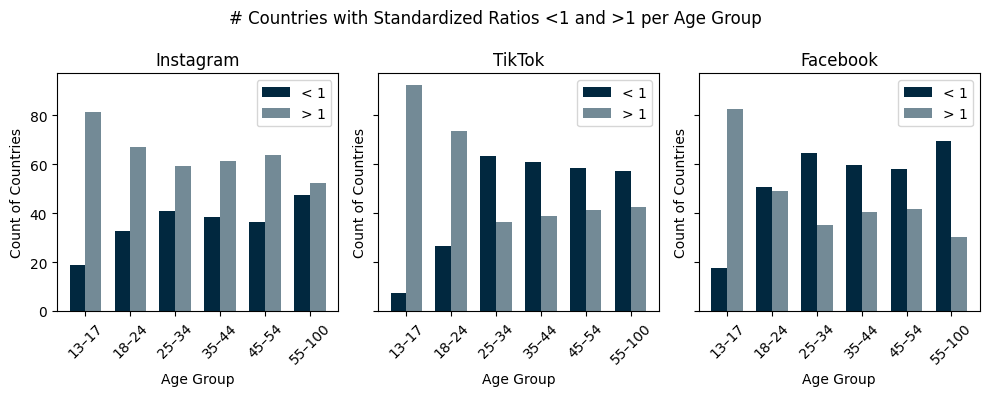

In [160]:
### Descriptives on Country Level Ratios
AGE_GROUPS = ['13_17', '18_24', '25_34', '35_44', '45_54', '55_100']

def count_gender_ratios(df: pd.DataFrame, name: str):
    counts = {}
    print(f"\n=== {name} ===")
    for group in AGE_GROUPS:
        ratio_col = f"age_{group}_ratio_std"
        if ratio_col in df.columns:
            col = df[ratio_col].dropna() 
            below = (col < 1).sum() /  len(col) * 100
            above = (col >= 1).sum() /  len(col) * 100
            equal = (col == 1).sum() /  len(col) * 100
            nan_count = df[ratio_col].isna().sum()
            max_val = col.max()
            min_val = col.min()
            max_name = df.loc[col.idxmax(), "iso3"] 
            min_name = df.loc[col.idxmin(), "iso3"] 

            print(f"\n Standardized Ratio for Age {group}:")
            print(f"  < 1: {below}, > 1: {above}, = 1: {equal}, empty: {nan_count}")
            print(f"  Max: {max_val:.2f} ({max_name})")
            print(f"  Min: {min_val:.2f} ({min_name})")

            counts[group] = {'<1': below, '>1': above}
    
    
    if "total_ratio_std" in df.columns:
        total_col = df["total_ratio_std"].dropna()
        total_below = (total_col< 1).sum() / len(total_col)*100
        total_above = (total_col >= 1).sum() / len(total_col)*100
        total_equal = (total_col == 1).sum() / len(total_col)*100
        max_val = total_col.max()
        min_val = total_col.min()
        max_name = df.loc[total_col.idxmax(), "iso3"] 
        min_name = df.loc[total_col.idxmin(), "iso3"] 

        print(f"\n Standardized Ratio Total:")
        print(f"  < 1: {total_below}, > 1: {total_above}, = 1: {total_equal}")
        print(f"  Max: {max_val:.2f} ({max_name})")
        print(f"  Min: {min_val:.2f} ({min_name})")
    return counts

# Run analysis for each file
datasets = {}
for file_path, name in FILE_NAMES.items():
    if name == "Population": # has no standardized ratio, hence skip
        continue
    df = pd.read_csv(file_path, sep=";")
    datasets[name] = count_gender_ratios(df, name)

# Analysis specific on TikTok Data. Values < 1000 indicate that dimension too small and data not reliable.
    if name == "TikTok":
        print(f"\n=== TikTok Estimate Check (<1000 users) ===")
        for group in AGE_GROUPS:
            for gender in ["women", "men"]:
                col = f"age_{group}_{gender}"
                if col in df.columns:
                    count = (df[col] < 1000).sum()
                    print(f"{col}: {count} entries below 1,000 out of {len(df[col])} total entries")

##### GRAPH

fig, axes = plt.subplots(1, len(datasets), figsize=(10, 4), sharey=True)

if len(datasets) == 1:
    axes = [axes]  # Make iterable if only one plot

age_labels = [age.replace('_', '–') for age in AGE_GROUPS]
x = np.arange(len(AGE_GROUPS))
bar_width = 0.35

for ax, (name, counts) in zip(axes, datasets.items()):
    below_counts = [counts[age]['<1'] if age in counts else 0 for age in AGE_GROUPS]
    above_counts = [counts[age]['>1'] if age in counts else 0 for age in AGE_GROUPS]

    ax.bar(x - bar_width/2, below_counts, width=bar_width, label='< 1', color = '#01283F')
    ax.bar(x + bar_width/2, above_counts, width=bar_width, label='> 1',color = '#738a96')

    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(age_labels, rotation=45)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Count of Countries')
    ax.legend()

plt.suptitle('# Countries with Standardized Ratios <1 and >1 per Age Group', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()


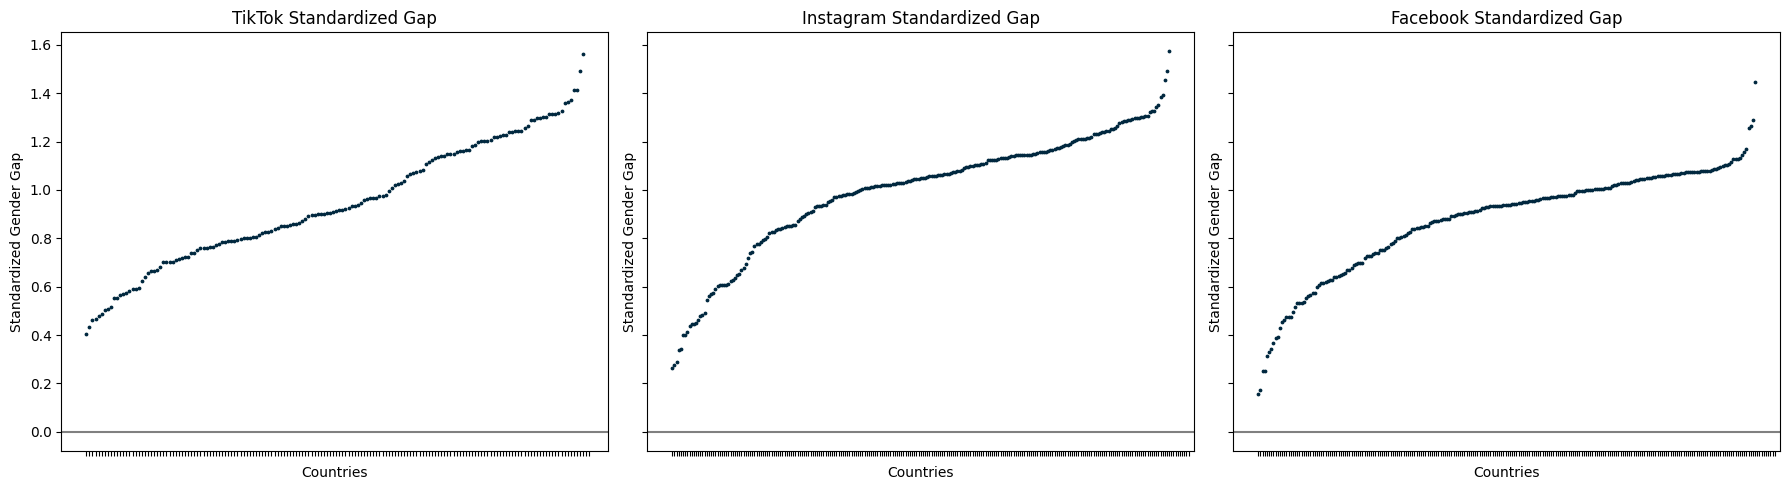

In [170]:
### Create Scatterplot of Tiktok Relative Gender Gap
tt_std = tt[["iso3","total_ratio_std"]].sort_values("total_ratio_std", ascending=True)
inst_std = inst[["iso3","total_ratio_std"]].sort_values("total_ratio_std", ascending=True)
fb_std = fb[["iso3","total_ratio_std"]].sort_values("total_ratio_std", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(tt_std["iso3"], tt_std["total_ratio_std"],color='#01283F', s=3)
axes[0].axhline(0, color='gray')
axes[0].set_title("TikTok Standardized Gap")
axes[0].set_xticklabels([])
axes[0].set_xlabel("Countries")
axes[0].set_ylabel("Standardized Gender Gap")
axes[0].grid(False)

axes[1].scatter(inst_std["iso3"], inst_std["total_ratio_std"],color='#01283F', s=3)
axes[1].axhline(0, color='gray')
axes[1].set_title("Instagram Standardized Gap")
axes[1].set_xticklabels([])
axes[1].set_xlabel("Countries")
axes[1].set_ylabel("Standardized Gender Gap")
axes[1].grid(False)

axes[2].scatter(fb_std["iso3"], fb_std["total_ratio_std"],color='#01283F', s=3)
axes[2].axhline(0, color='gray')
axes[2].set_title("Facebook Standardized Gap")
axes[2].set_xticklabels([])
axes[2].set_xlabel("Countries")
axes[2].set_ylabel("Standardized Gender Gap")
axes[2].grid(False)

plt.tight_layout()
plt.show()

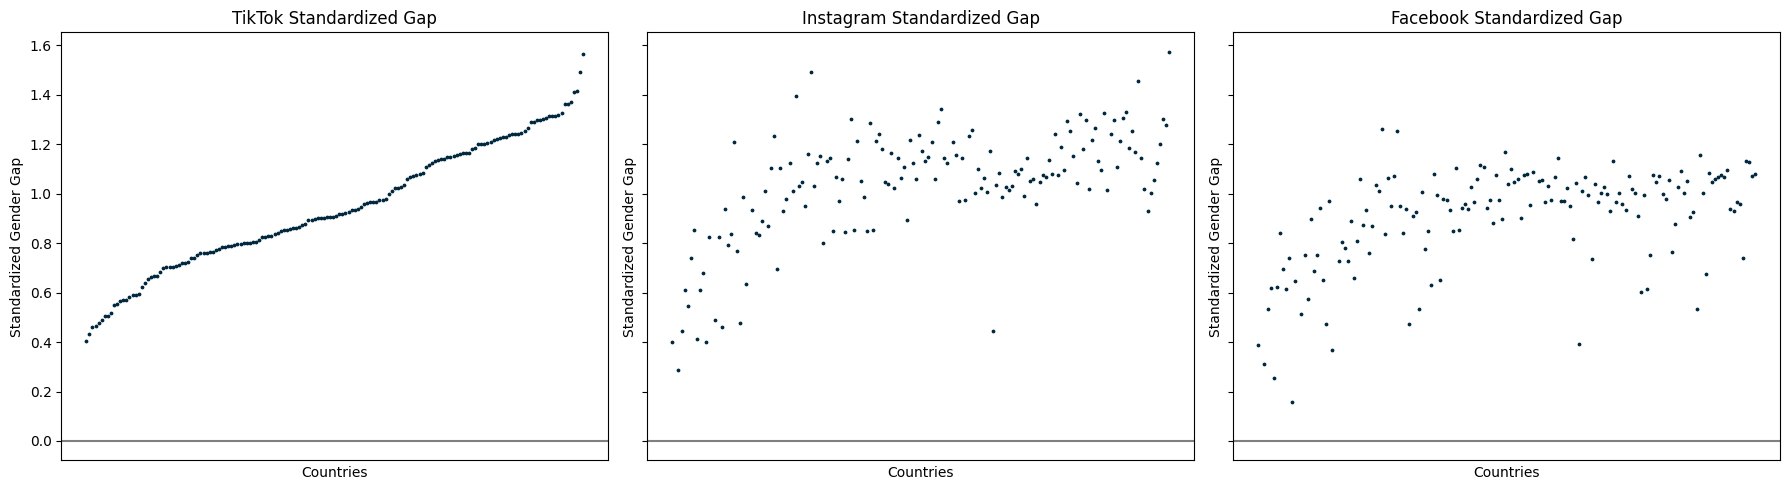

In [172]:
# Step 1: Define consistent country order based on TikTok data
country_order = tt[["iso3", "total_ratio_std"]].sort_values("total_ratio_std", ascending=True)["iso3"]

# Step 2: Reindex all datasets to the same country order based on TikTok
tt_std = tt.set_index("iso3").reindex(country_order).reset_index()
inst_std = inst.set_index("iso3").reindex(country_order).reset_index()
fb_std = fb.set_index("iso3").reindex(country_order).reset_index()

# Step 3: Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(tt_std["iso3"], tt_std["total_ratio_std"], color='#01283F', s=3)
axes[0].axhline(0, color='gray')
axes[0].set_title("TikTok Standardized Gap")
axes[0].set_xticks([])
axes[0].set_xlabel("Countries")
axes[0].set_ylabel("Standardized Gender Gap")
axes[0].grid(False)

axes[1].scatter(inst_std["iso3"], inst_std["total_ratio_std"], color='#01283F', s=3)
axes[1].axhline(0, color='gray')
axes[1].set_title("Instagram Standardized Gap")
axes[1].set_xticks([])
axes[1].set_xlabel("Countries")
axes[1].set_ylabel("Standardized Gender Gap")
axes[1].grid(False)

axes[2].scatter(fb_std["iso3"], fb_std["total_ratio_std"], color='#01283F', s=3)
axes[2].axhline(0, color='gray')
axes[2].set_title("Facebook Standardized Gap")
axes[2].set_xticks([])
axes[2].set_xlabel("Countries")
axes[2].set_ylabel("Standardized Gender Gap")
axes[2].grid(False)

plt.tight_layout()
plt.show()



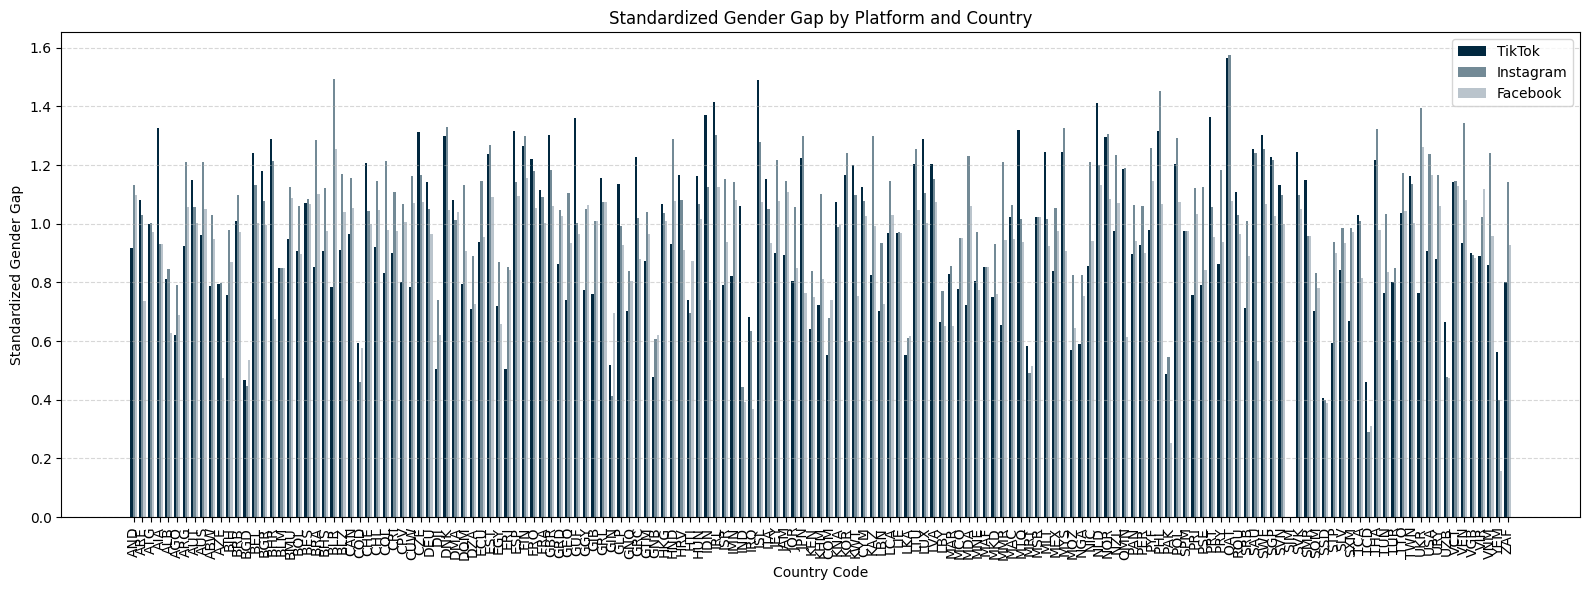

In [140]:
# Compare sources side by side
merged = tt[["iso3", "total_ratio_std"]].merge(inst[["iso3", "total_ratio_std"]], on="iso3", suffixes=("_tt", "_inst")).merge(fb[["iso3", "total_ratio_std"]], on="iso3").rename(columns={"total_ratio_std": "total_ratio_std_fb"})

# Sort by TikTok for visual clarity
#merged = merged.sort_values("total_ratio_std_tt", ascending=True)

# Plot
x = merged["iso3"]
x_pos = range(len(x))

plt.figure(figsize=(16, 6))
bar_width = 0.25

plt.bar([i - bar_width for i in x_pos], merged["total_ratio_std_tt"], width=bar_width, label='TikTok', color='#01283F')
plt.bar(x_pos, merged["total_ratio_std_inst"], width=bar_width, label='Instagram', color='#738a96')
plt.bar([i + bar_width for i in x_pos], merged["total_ratio_std_fb"], width=bar_width, label='Facebook', color='#bac4cc')

plt.xticks(x_pos, x, rotation=90)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Country Code")
plt.ylabel("Standardized Gender Gap")
plt.title("Standardized Gender Gap by Platform and Country")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

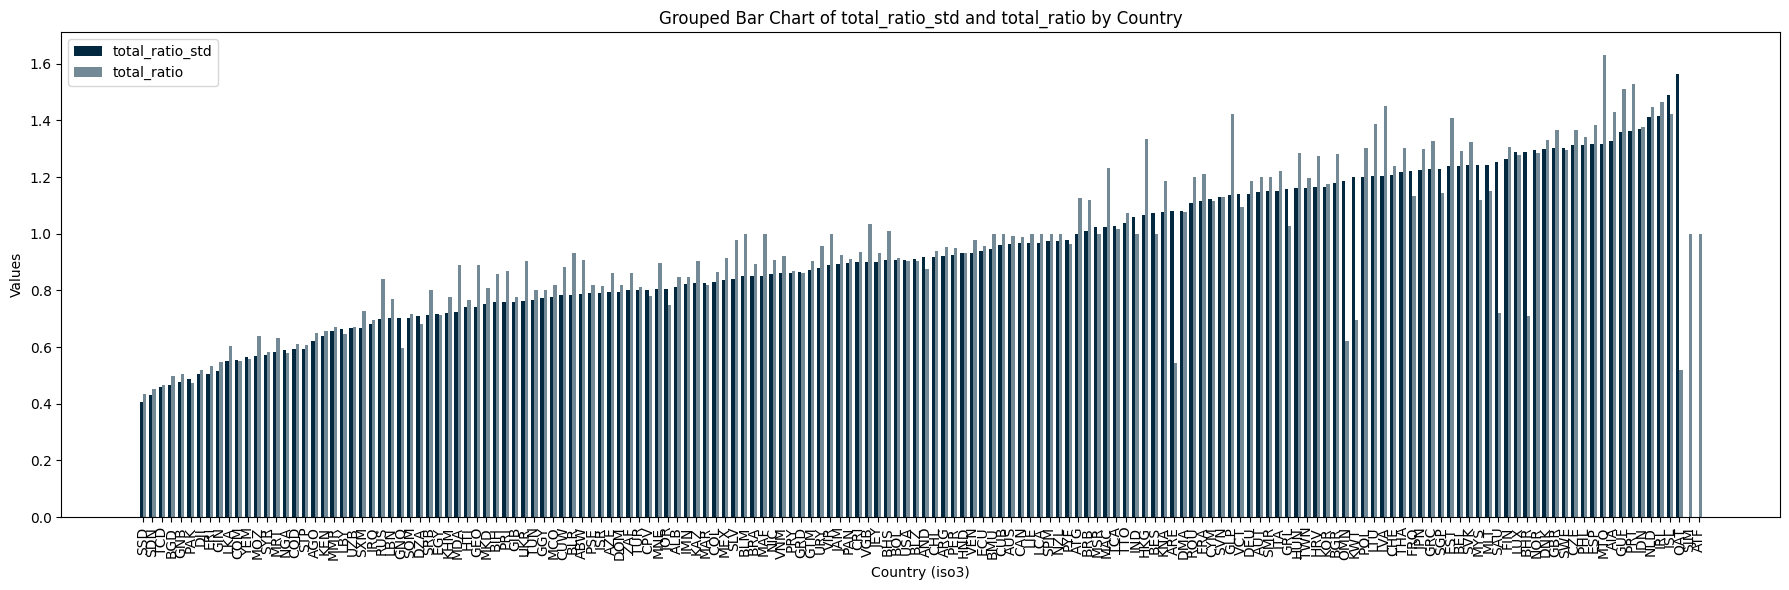

In [141]:
# compare TikTok gap vs standardized gap
merged = tt[["iso3", "total_ratio_std", "total_ratio"]].sort_values("total_ratio_std", ascending=True)

countries = merged["iso3"]
std_values = merged["total_ratio_std"]
raw_values = merged["total_ratio"]

x = np.arange(len(countries))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(18,6))
bars1 = ax.bar(x - width/2, std_values, width, label='total_ratio_std', color= '#01283F')
bars2 = ax.bar(x + width/2, raw_values, width, label='total_ratio', color='#738a96')

# Add labels, title, and legend
ax.set_xlabel('Country (iso3)')
ax.set_ylabel('Values')
ax.set_title('Grouped Bar Chart of total_ratio_std and total_ratio by Country')
ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [118]:
print(tt.columns.to_list())

['level', 'iso2', 'name', 'age_13_17_women', 'age_13_17_men', 'age_18_24_women', 'age_18_24_men', 'age_25_34_women', 'age_25_34_men', 'age_35_44_women', 'age_35_44_men', 'age_45_54_women', 'age_45_54_men', 'age_55_100_women', 'age_55_100_men', 'age_13_17_ratio', 'age_18_24_ratio', 'age_25_34_ratio', 'age_35_44_ratio', 'age_45_54_ratio', 'age_55_100_ratio', 'total_men', 'total_women', 'total_all', 'total_ratio', 'iso3', 'age_13_17_ratio_std', 'age_18_24_ratio_std', 'age_25_34_ratio_std', 'age_35_44_ratio_std', 'age_45_54_ratio_std', 'age_55_100_ratio_std', 'total_ratio_std', 'age_13_17_women_pen', 'age_13_17_men_pen', 'age_18_24_women_pen', 'age_18_24_men_pen', 'age_25_34_women_pen', 'age_25_34_men_pen', 'age_35_44_women_pen', 'age_35_44_men_pen', 'age_45_54_women_pen', 'age_45_54_men_pen', 'age_55_100_women_pen', 'age_55_100_men_pen', 'total_men_pen', 'total_women_pen', 'total_all_pen']


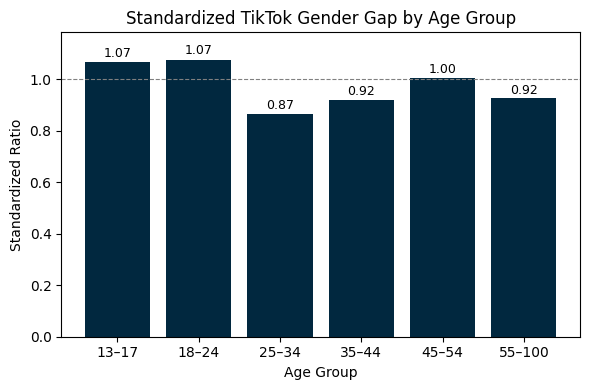

In [142]:
age_groups = ['13_17', '18_24', '25_34', '35_44', '45_54', '55_100']

# Columns for men and women counts per age group
women_cols = [f'age_{age}_women' for age in age_groups]
men_cols = [f'age_{age}_men' for age in age_groups]

tt_ratios = []
pop_ratios = []

for w_col, m_col in zip(women_cols, men_cols):
    # Sum over all rows for each column
    tt_women_sum = tt[w_col].sum()
    tt_men_sum = tt[m_col].sum()
    pop_women_sum = pop[w_col].sum()
    pop_men_sum = pop[m_col].sum()
    
    # Calculate women/men ratio per dataset
    tt_ratio = tt_women_sum / tt_men_sum if tt_men_sum != 0 else np.nan
    pop_ratio = pop_women_sum / pop_men_sum if pop_men_sum != 0 else np.nan
    
    tt_ratios.append(tt_ratio)
    pop_ratios.append(pop_ratio)

std_ratios = np.array(tt_ratios) / np.array(pop_ratios)

age_labels = [age.replace('_', '–') for age in age_groups]

plt.figure(figsize=(6,4))
bars = plt.bar(age_labels, std_ratios, color='#01283F')
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)  # baseline at 1
plt.title('Standardized TikTok Gender Gap by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Standardized Ratio')
plt.ylim([0, np.nanmax(std_ratios) * 1.1])

# Optional: annotate values on bars
for bar, value in zip(bars, std_ratios):
    plt.text(bar.get_x() + bar.get_width()/2, value * 1.02, f'{value:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()



In [143]:
# TikTok descriptive table summary
ratio_columns = [col for col in tt.columns if col.endswith("_ratio_std")]
summary = tt[ratio_columns].agg(["min", "max", "mean", "std"]).transpose()

summary.columns = ["Min", "Max", "Mean", "Std Dev"]
summary.rename(index={
    'age_13_17_ratio_std': '13–17',
    'age_18_24_ratio_std': '18–24',
    'age_25_34_ratio_std': '25–34',
    'age_35_44_ratio_std': '35–44',
    'age_45_54_ratio_std': '45–54',
    'age_55_100_ratio_std': '55+',
    'total_ratio_std':'total'
}, inplace=True)

print(summary)

          Min     Max      Mean   Std Dev
13–17  0.8482  1.1600  1.044129  0.036413
18–24  0.3187  3.0659  1.147377  0.352310
25–34  0.3061  1.6695  0.928366  0.294277
35–44  0.3074  2.7034  0.943073  0.343815
45–54  0.3089  3.1204  0.987922  0.391164
55+    0.2808  3.0124  1.006808  0.401839
total  0.4056  1.5646  0.941902  0.254495


In [112]:
ratio_columns = [col for col in tt.columns if col.endswith("_ratio_std")]

# Get top 10 by age_18_24_ratio_std
top_iso3 = tt[['iso3', 'age_18_24_ratio_std']].sort_values(by='age_18_24_ratio_std', ascending=False).head(10)['iso3']

# Filter original df for those iso3 and show only iso3 + all ratio columns
top_df = tt[tt['iso3'].isin(top_iso3)][['iso3'] + ratio_columns]

#print(top_df)

#print(tt.loc[tt["iso3"] == "MSR", "total_all"])
max_row = tt.loc[tt['age_35_44_ratio_std'].idxmax()]
print(max_row)

#print(tt.loc[tt["iso3"] == "AIA", "age_18_24_ratio"])
#print(tt.loc[tt["iso3"] == "AIA", "age_18_24_women"])
print(pop.loc[pop["iso3"] == "VIR"])

level                    country
iso2                          AI
name                    Anguilla
age_13_17_women            500.0
age_13_17_men              500.0
age_18_24_women           4000.0
age_18_24_men             1500.0
age_25_34_women           3000.0
age_25_34_men             3500.0
age_35_44_women           1500.0
age_35_44_men              500.0
age_45_54_women            500.0
age_45_54_men              500.0
age_55_100_women           500.0
age_55_100_men             500.0
age_13_17_ratio              1.0
age_18_24_ratio           2.6667
age_25_34_ratio           0.8571
age_35_44_ratio              3.0
age_45_54_ratio              1.0
age_55_100_ratio             1.0
total_men                 7000.0
total_women              10000.0
total_all                17000.0
total_ratio               1.4286
iso3                         AIA
age_13_17_ratio_std     0.978665
age_18_24_ratio_std      2.72029
age_25_34_ratio_std     0.869358
age_35_44_ratio_std     2.703433
age_45_54_

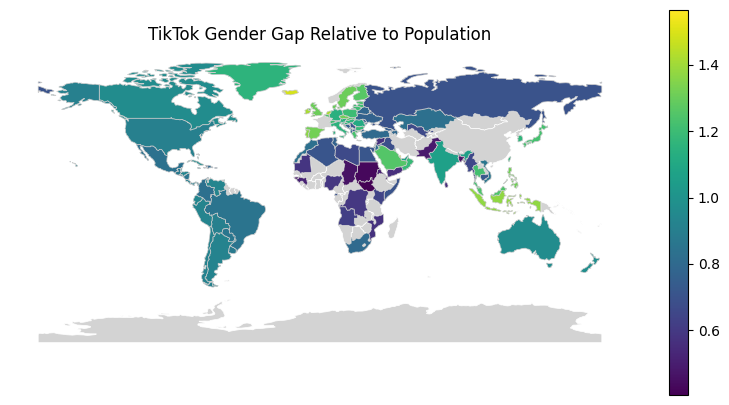

In [144]:
# creating map of tiktok 
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load world geometry
world = gpd.read_file("../../data/raw/map/ne_110m_admin_0_countries.shp")
tt_std1 = tt_std.rename(columns={"iso3":"ISO_A3"})

merged = world.merge(tt_std1, on='ISO_A3', how='left')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

merged.dropna(subset=["total_ratio_std"]).plot(
    column='total_ratio_std',
    cmap='viridis',
    linewidth=0.5,
    edgecolor='0.8',
    legend=True,
    ax=ax
)

ax.set_title('TikTok Gender Gap Relative to Population')
plt.axis('off')
plt.show()



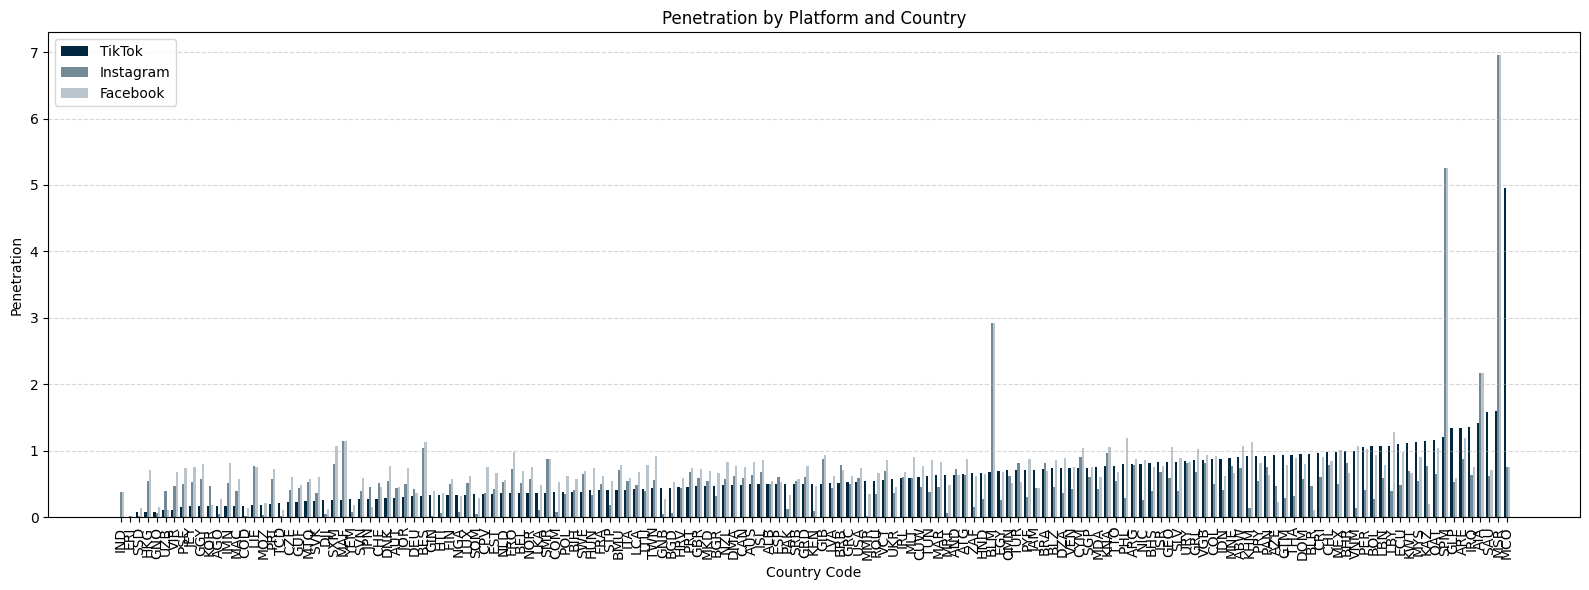

In [147]:
# Compare penetration side by side
merged = tt[["iso3", "total_all_pen"]].merge(inst[["iso3", "total_all_pen"]], on="iso3", suffixes=("_tt", "_inst")).merge(fb[["iso3", "total_all_pen"]], on="iso3").rename(columns={"total_all_pen": "total_penetration"})
merged = merged[~merged["iso3"].isin(["TCA", "SJM"])]

# Sort by TikTok for visual clarity
merged = merged.sort_values("total_all_pen_tt", ascending=True)


# Plot
x = merged["iso3"]
x_pos = range(len(x))

plt.figure(figsize=(16, 6))
bar_width = 0.25

plt.bar([i - bar_width for i in x_pos], merged["total_all_pen_tt"], width=bar_width, label='TikTok', color= '#01283F')
plt.bar(x_pos, merged["total_all_pen_inst"], width=bar_width, label='Instagram', color='#738a96')
plt.bar([i + bar_width for i in x_pos], merged["total_penetration"], width=bar_width, label='Facebook', color='#bac4cc')

plt.xticks(x_pos, x, rotation=90)
plt.axhline(0, color='gray', linewidth=0.5)
plt.xlabel("Country Code")
plt.ylabel("Penetration")
plt.title("Penetration by Platform and Country")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [148]:
print(tt.loc[tt["iso3"] == "TCA", "total_all"])
print(pop.loc[pop["iso3"] == "TCA", "total_all"])
t = tt.loc[tt["iso3"] == "TCA", "total_all"]
p = pop.loc[pop["iso3"] == "TCA", "total_all"]
print(t.values[0]/p.values[0])

tt_tca = tt[tt['iso3'] == 'TCA']
pop_tca = pop[pop['iso3'] == 'TCA']
print(tt_tca.T)

145    1006000.0
Name: total_all, dtype: float64
203    39060.0
Name: total_all, dtype: float64
25.755248335893498
                                           145
level                                  country
iso2                                        TC
name                  Turks and Caicos Islands
age_13_17_women                          500.0
age_13_17_men                            500.0
age_18_24_women                       127500.0
age_18_24_men                         124000.0
age_25_34_women                       178500.0
age_25_34_men                         180500.0
age_35_44_women                        94000.0
age_35_44_men                         104000.0
age_45_54_women                        55000.0
age_45_54_men                          49500.0
age_55_100_women                       51500.0
age_55_100_men                         40500.0
age_13_17_ratio                            1.0
age_18_24_ratio                         1.0282
age_25_34_ratio                        

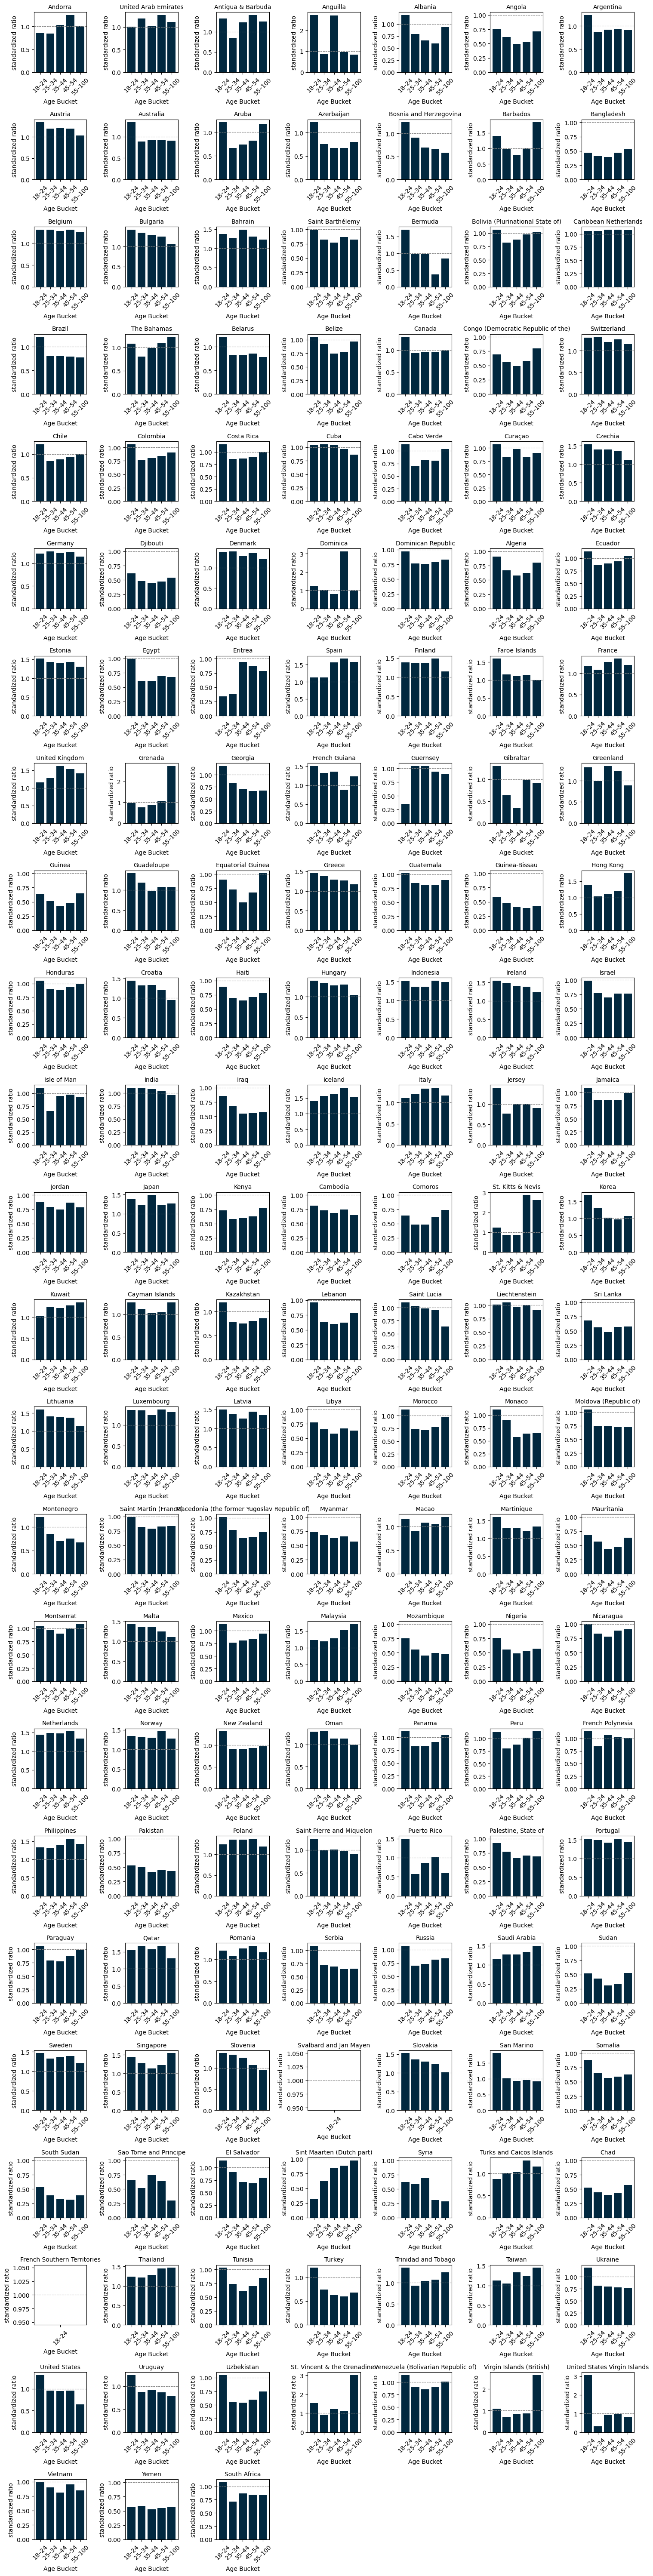

In [173]:
# bar charts per age and country

age_groups = [ '18_24', '25_34', '35_44', '45_54', '55_100']
ratio_cols = [f'age_{age}_ratio_std' for age in age_groups if f'age_{age}_ratio_std' in tt.columns]
age_labels = [age.replace('_', '–') for age in age_groups if f'age_{age}_ratio_std' in tt.columns]


# Get unique countries
countries = tt['iso3'].unique()

# Calculate grid dimensions
n_countries = len(countries)
cols = 7  # or adjust based on your preference
rows = int(np.ceil(n_countries / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 2.5*rows))
axes = axes.flatten() if n_countries > 1 else [axes]

# Create bar chart for each country
for i, country in enumerate(countries):
    row = tt[tt['iso3'] == country].iloc[0]
    values = [row[col] for col in ratio_cols]
    country_name = tt.loc[tt['iso3'] == country, 'name'].values[0]
    
    axes[i].bar(age_labels, values, color='#01283F')
    axes[i].set_title(f'{country_name}',fontsize=10)
    axes[i].set_xlabel('Age Bucket')
    axes[i].set_ylabel('standardized ratio')
    axes[i].axhline(1, linestyle='--', color='gray', linewidth=0.8)  # gender parity line
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for i in range(n_countries, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

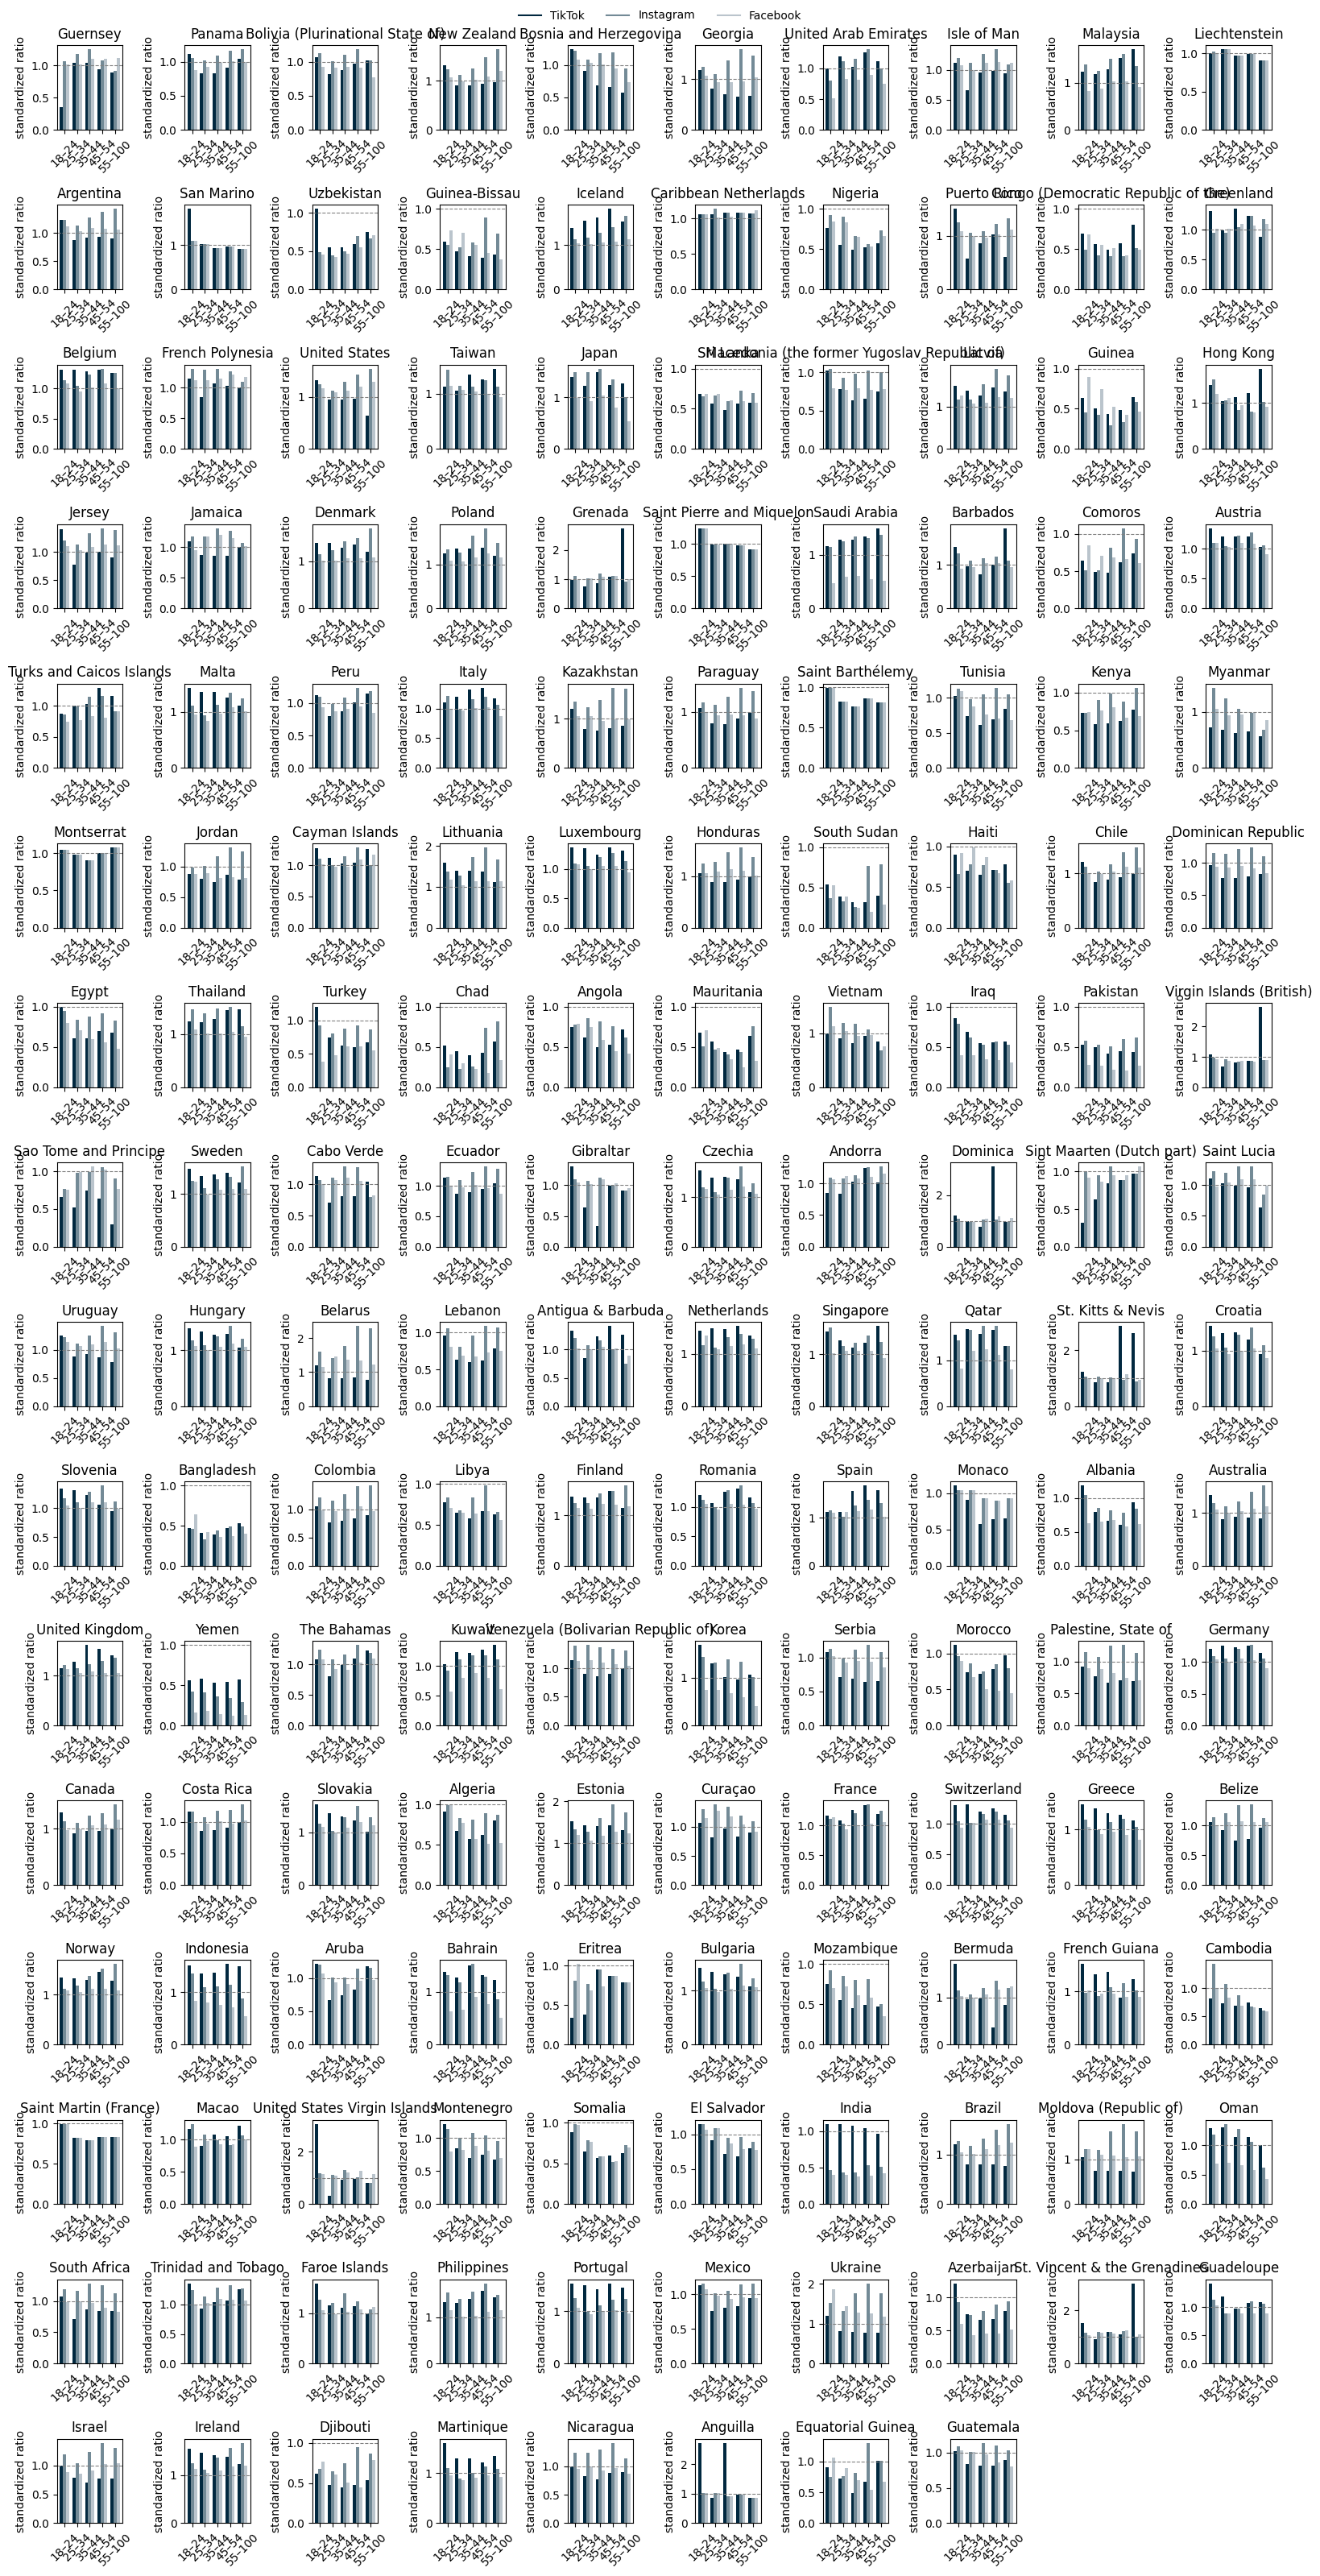

In [176]:
# bar charts per age and country by platform

age_groups = [ '18_24', '25_34', '35_44', '45_54', '55_100']
ratio_cols = [f'age_{age}_ratio_std' for age in age_groups if f'age_{age}_ratio_std' in tt.columns]
age_labels = [age.replace('_', '–') for age in age_groups if f'age_{age}_ratio_std' in tt.columns]


# Get unique countries
countries = list(set(tt['iso3']).intersection(fb['iso3']).intersection(inst['iso3']) - {'SJM'})

# Calculate grid dimensions
n_countries = len(countries)
cols = 10  # or adjust based on your preference
rows = int(np.ceil(n_countries / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 2*rows))
axes = axes.flatten() if n_countries > 1 else [axes]

bar_width = 0.25
x = np.arange(len(age_labels))  # one position per age group

# Create bar chart for each country
for i, country in enumerate(countries):
    row_tt = tt[tt['iso3'] == country].iloc[0]
    row_fb = fb[fb['iso3'] == country].iloc[0]
    row_inst = inst[inst['iso3'] == country].iloc[0]
    values_tt = [row_tt[col] for col in ratio_cols]
    values_fb = [row_fb[col] for col in ratio_cols]
    values_inst = [row_inst[col] for col in ratio_cols]
    
    axes[i].bar(x - bar_width, values_tt, width=bar_width, label='TT', color='#01283F')
    axes[i].bar(x, values_inst, width=bar_width, label='INSTA', color='#738a96')
    axes[i].bar(x + bar_width, values_fb, width=bar_width, label='FB', color='#bac4cc')

    country_name = tt.loc[tt['iso3'] == country, 'name'].values[0]

    axes[i].set_title(f'{country_name}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(age_labels, rotation=45)
    axes[i].set_ylabel('standardized ratio')
    axes[i].axhline(1, linestyle='--', color='gray', linewidth=0.8)  # gender parity line

# Hide empty subplots
for i in range(n_countries, len(axes)):
    axes[i].axis('off')

platforms = [
    plt.Line2D([], [], color='#01283F', label='TikTok'),
    plt.Line2D([], [], color='#738a96', label='Instagram'),
    plt.Line2D([], [], color='#bac4cc', label='Facebook')
]
fig.legend(handles=platforms, loc='upper center', ncol=3, frameon=False, fontsize='medium')

plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.show()